<a href="https://colab.research.google.com/github/suchanabiswas06-ship-it/Suchana-Biswas-AI-Lab/blob/main/AI%20LAB%20TASK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BFS Traversal:
['A', 'B', 'C', 'D', 'E', 'F']

DFS Traversal:
['A', 'B', 'D', 'E', 'C', 'F']


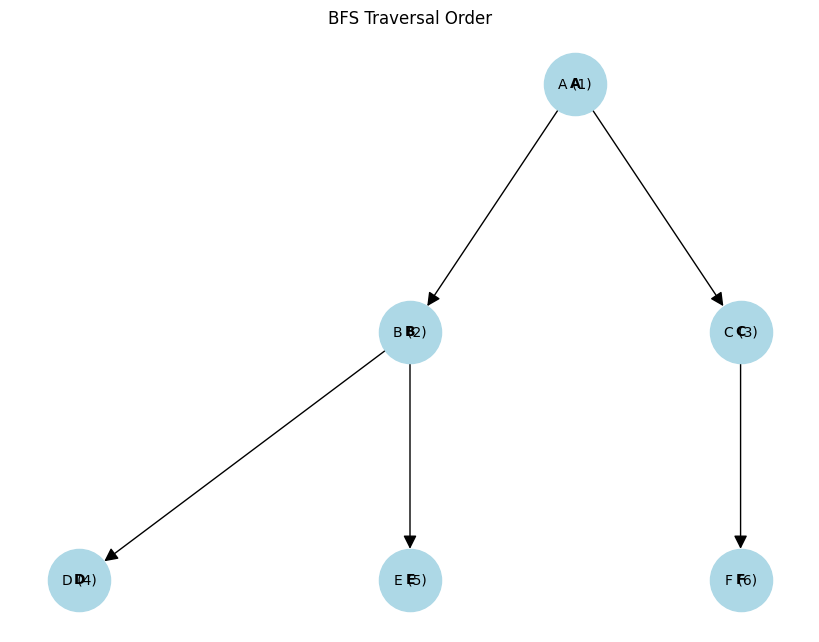

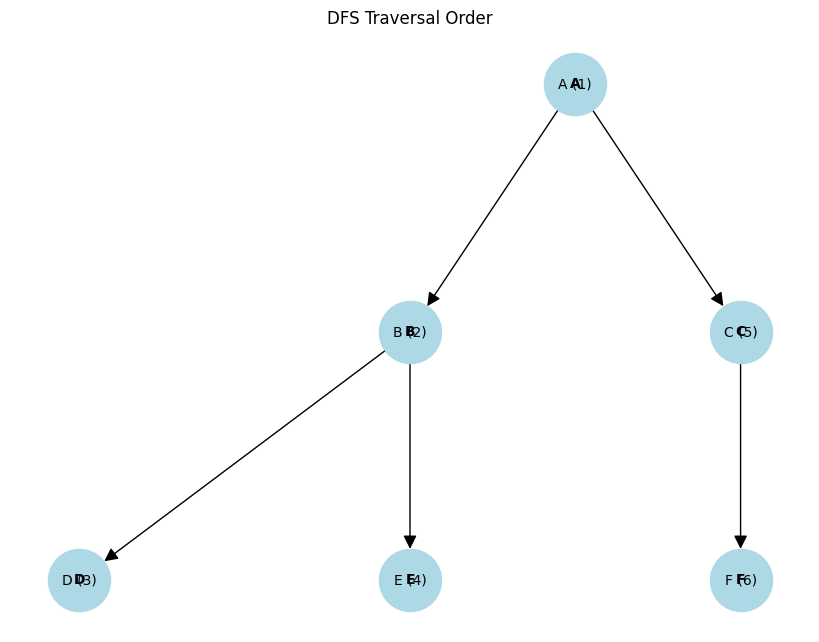

In [5]:
!pip install pygraphviz
import collections
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B'],
    'F': ['C']
}

directed_graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

def bfs(graph, start_node):
    visited = []
    queue = collections.deque([start_node])
    visit_order = {}
    count = 1

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            visit_order[node] = count
            count += 1
            for neighbor in graph.get(node, []):
                if neighbor not in visited:
                    queue.append(neighbor)
    return visited, visit_order

def dfs(graph, start_node):
    visited = []
    stack = [start_node]
    visit_order = {}
    count = 1

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.append(node)
            visit_order[node] = count
            count += 1
            for neighbor in reversed(graph.get(node, [])):
                if neighbor not in visited:
                    stack.append(neighbor)
    return visited, visit_order

print("BFS Traversal:")
bfs_order_list, bfs_visit_order_dict = bfs(directed_graph, 'A')
print(bfs_order_list)

print("\nDFS Traversal:")
dfs_order_list, dfs_visit_order_dict = dfs(directed_graph, 'A')
print(dfs_order_list)

def draw_traversal(graph_dict, visit_order_dict, title):
    G = nx.DiGraph(graph_dict)

    pos = nx.drawing.nx_agraph.graphviz_layout(G, prog='dot')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)

    node_labels = {node: f'{node} ({visit_order_dict[node]})' for node in G.nodes() if node in visit_order_dict}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_color='black')

    plt.title(title)
    plt.axis('off')
    plt.show()

draw_traversal(directed_graph, bfs_visit_order_dict, 'BFS Traversal Order')

draw_traversal(directed_graph, dfs_visit_order_dict, 'DFS Traversal Order')

Water Jug Problem Solution (BFS):
Step 1: (0, 0) --(Fill Jug B)--> (0, 3)
Step 2: (0, 3) --(Pour B to A)--> (3, 0)
Step 3: (3, 0) --(Fill Jug B)--> (3, 3)
Step 4: (3, 3) --(Pour B to A)--> (4, 2)
Final State: (4, 2)


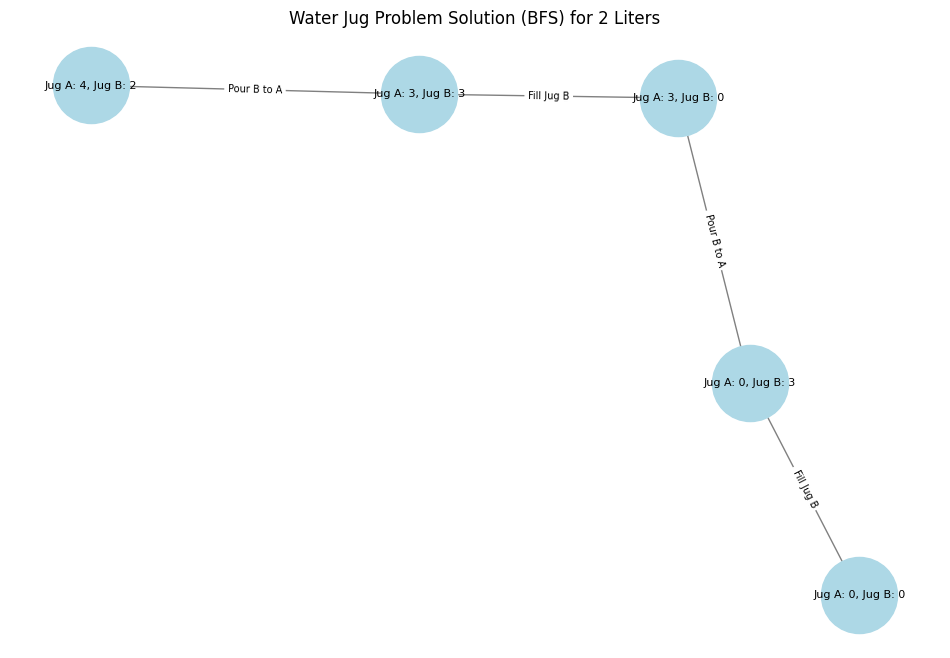

In [6]:
import collections
import networkx as nx
import matplotlib.pyplot as plt

JUG_A_CAP = 4
JUG_B_CAP = 3
TARGET_AMOUNT = 2

def get_next_states(current_state, cap_a, cap_b):
    a, b = current_state
    next_states = []

    next_states.append(((cap_a, b), 'Fill Jug A'))
    next_states.append(((a, cap_b), 'Fill Jug B'))
    next_states.append(((0, b), 'Empty Jug A'))
    next_states.append(((a, 0), 'Empty Jug B'))

    if a > 0 and b < cap_b:
        pour_amount = min(a, cap_b - b)
        next_states.append(((a - pour_amount, b + pour_amount), 'Pour A to B'))

    if b > 0 and a < cap_a:
        pour_amount = min(b, cap_a - a)
        next_states.append(((a + pour_amount, b - pour_amount), 'Pour B to A'))

    return [(state, op) for state, op in next_states if state != current_state]

def solve_water_jug_bfs(cap_a, cap_b, target):
    start_state = (0, 0)
    queue = collections.deque([(start_state, [])])
    visited = {start_state}

    while queue:
        current_state, path = queue.popleft()
        a, b = current_state

        if a == target or b == target:
            return path + [current_state]

        for next_state_tuple, operation in get_next_states(current_state, cap_a, cap_b):
            if next_state_tuple not in visited:
                visited.add(next_state_tuple)
                new_path = path + [current_state]
                queue.append((next_state_tuple, new_path))

    return None

def reconstruct_detailed_path(start_state, solution_path_states, cap_a, cap_b):
    if not solution_path_states:
        return []

    detailed_path = []
    current_state = start_state

    for i in range(len(solution_path_states) - 1):
        next_state = solution_path_states[i+1]
        found_op = False
        for possible_next, operation_name in get_next_states(current_state, cap_a, cap_b):
            if possible_next == next_state:
                detailed_path.append((current_state, operation_name, next_state))
                current_state = next_state
                found_op = True
                break
        if not found_op:
            print(f"Warning: Could not find operation from {current_state} to {next_state}")
            break

    return detailed_path

solution_states = solve_water_jug_bfs(JUG_A_CAP, JUG_B_CAP, TARGET_AMOUNT)

print("Water Jug Problem Solution (BFS):")
if solution_states:
    if solution_states[0] != (0,0):
        solution_states.insert(0, (0,0))
    detailed_solution_path = reconstruct_detailed_path((0,0), solution_states, JUG_A_CAP, JUG_B_CAP)

    for i, (state_before, op, state_after) in enumerate(detailed_solution_path):
        print(f"Step {i+1}: {state_before} --({op})--> {state_after}")
    print(f"Final State: {solution_states[-1]}")

    G = nx.DiGraph()

    for i, (state_before, op, state_after) in enumerate(detailed_solution_path):
        G.add_node(state_before, label=f'Jug A: {state_before[0]}, Jug B: {state_before[1]}')
        G.add_node(state_after, label=f'Jug A: {state_after[0]}, Jug B: {state_after[1]}')
        G.add_edge(state_before, state_after, label=op)

    final_state = solution_states[-1]
    G.add_node(final_state, label=f'Jug A: {final_state[0]}, Jug B: {final_state[1]}')

    pos = nx.spring_layout(G, k=0.5, iterations=50)
    plt.figure(figsize=(12, 8))
    plt.title(f'Water Jug Problem Solution (BFS) for {TARGET_AMOUNT} Liters')

    node_labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrowsize=20)

    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, label_pos=0.5)

    plt.axis('off')
    plt.show()
else:
    print("No solution found.")


--- Route Existence Check ---
Route from CityA to CityD: True
Route from CityA to CityF: False
Route from CityF to CityH: False

--- Connected Components ---
Component 1: ['CityA', 'CityB', 'CityD', 'CityC', 'CityE']
Component 2: ['CityF', 'CityG']
Component 3: ['CityH']


/tmp/ipykernel_3590/489513539.py:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('viridis', len(components))


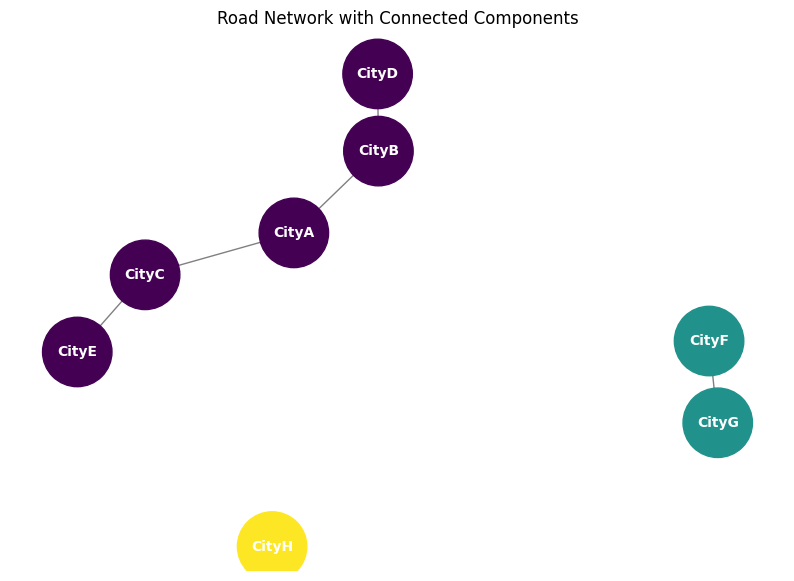

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

road_network = {
    'CityA': ['CityB', 'CityC'],
    'CityB': ['CityA', 'CityD'],
    'CityC': ['CityA', 'CityE'],
    'CityD': ['CityB'],
    'CityE': ['CityC'],
    'CityF': ['CityG'],
    'CityG': ['CityF'],
    'CityH': []
}

def dfs_has_route(graph, start_city, end_city):
    visited = set()
    stack = [start_city]

    while stack:
        current_city = stack.pop()
        if current_city == end_city:
            return True
        if current_city not in visited:
            visited.add(current_city)
            for neighbor in sorted(graph.get(current_city, []), reverse=True):
                if neighbor not in visited:
                    stack.append(neighbor)
    return False

def dfs_connected_components(graph):
    visited_global = set()
    connected_components = []

    for city in graph:
        if city not in visited_global:
            current_component = []
            stack = [city]
            visited_local = set()

            while stack:
                current_node = stack.pop()
                if current_node not in visited_local:
                    visited_local.add(current_node)
                    visited_global.add(current_node)
                    current_component.append(current_node)
                    for neighbor in sorted(graph.get(current_node, []), reverse=True):
                        if neighbor not in visited_local:
                            stack.append(neighbor)
            connected_components.append(current_component)
    return connected_components

print("\n--- Route Existence Check ---")
start_route1, end_route1 = 'CityA', 'CityD'
route_exists1 = dfs_has_route(road_network, start_route1, end_route1)
print(f"Route from {start_route1} to {end_route1}: {route_exists1}")

start_route2, end_route2 = 'CityA', 'CityF'
route_exists2 = dfs_has_route(road_network, start_route2, end_route2)
print(f"Route from {start_route2} to {end_route2}: {route_exists2}")

start_route3, end_route3 = 'CityF', 'CityH'
route_exists3 = dfs_has_route(road_network, start_route3, end_route3)
print(f"Route from {start_route3} to {end_route3}: {route_exists3}")

print("\n--- Connected Components ---")
components = dfs_connected_components(road_network)
for i, component in enumerate(components):
    print(f"Component {i+1}: {component}")

G = nx.Graph(road_network)

plt.figure(figsize=(10, 7))
plt.title("Road Network with Connected Components")

pos = nx.spring_layout(G, k=0.8, iterations=50)

color_map = plt.cm.get_cmap('viridis', len(components))
node_colors = []
for node in G.nodes():
    for i, component in enumerate(components):
        if node in component:
            node_colors.append(color_map(i))
            break

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='white')

plt.axis('off')
plt.show()




